# 1. Metropolis MCMC

## 1.a. 

We write a basic Metropolis MCMC algorithm (i.e., without using a MCMC software
package).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner

In [2]:
def metropolis_sampler(theta0, log_posterior, sigma, n_samples):
    """ Sample posterior with Metropolis MCMC algorithm """

    n_params = len(theta0)

    # initialize chain of positions in param space and corresponding log posterior
    chain = np.zeros((n_samples, n_params))
    chain[0] = theta0
    logP = np.zeros(n_samples)
    logP[0] = log_posterior(theta0)
    
    n_accepted = 0 #track acceptance rate
    
    for i in range(1, n_samples):
        theta_curr = chain[i-1]
        logP_curr = logP[i-1]
        
        # propose move in param space by drawing from a (gaussian) kernel
        theta_proposed = np.random.normal(loc=theta_curr, scale=sigma)
        logP_proposed = log_posterior(theta_proposed)
        
        # acceptance criterion
        log_ratio = logP_proposed - logP_curr
        r = np.random.uniform() # 0<=r<1
        
        # decide whether to make the move
        if np.log(r) < log_ratio:
            # exploitation: always move towards higher posterior 
            # (if 1 < ratio, then r < ratio is always true)
            # exploration: sometimes move towards lower posterior 
            # (if ratio < 1, then r < ratio is true w/ probability <ratio>)
            chain[i] = theta_proposed
            logP[i] = logP_proposed
            n_accepted += 1
        else:
            chain[i] = theta_curr
            logP[i] = logP_curr
    
    acceptance_rate = n_accepted / n_samples
    return chain, logP, acceptance_rate

In [3]:
def trace_plot(theta_explored, param_labels, burnin=0):
    n_params = len(param_labels)
    n_steps = theta_explored.shape[0]
    
    fig, ax = plt.subplots(n_params, 1, figsize=(10,3*n_params), sharex=True)
    plt.suptitle("Trace plot")

    for i, lab in enumerate(param_labels):
        ax[i].plot(range(burnin, n_steps), theta_explored[burnin:, i])
        ax[i].plot(range(burnin), theta_explored[0:burnin, i], label='burn-in')
        ax[i].set_ylabel(lab)
    ax[-1].set_xlabel('Iterations/steps')
    
    if burnin:
        ax[0].legend(loc=1)
    plt.tight_layout()
    plt.show()

## 1.b. 
W re-perform the best fit from Homework 1 Question 1 using a Bayesian approach with this
Metropolis MCMC code, and plot the posteriors (e.g., in a corner plot).

In [4]:
from astropy.io import fits
from astropy.table import Table

# loading lightcurve data
hdul = fits.open('./ztf_3C273_g.fits')
hdul.info()
#header = hdul[0].header
data = Table(hdul[1].data)
df = data.to_pandas()
print('\nExtracted table data:\n', df[:5])
hdul.close()

Filename: ./ztf_3C273_g.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  Table         1 BinTableHDU     81   667R x 24C   [1K, 1J, 1D, 1D, 1E, 1E, 1J, 2A, 1D, 1D, 1E, 1E, 1K, 1J, 1B, 1B, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J]   

Extracted table data:
                oid     expid           hjd           mjd        mag    magerr  \
0  473101200004287  45030090  2.458205e+06  58204.300903  13.121748  0.014404   
1  473101200004287  45031700  2.458205e+06  58204.317002  13.115712  0.014409   
2  473101200004287  45630146  2.458211e+06  58210.301470  13.139680  0.014388   
3  473101200004287  45632349  2.458211e+06  58210.323495  13.185056  0.014350   
4  473101200004287  45734530  2.458212e+06  58211.345301  13.133057  0.014394   

   catflags filtercode          ra       dec  ...  ccdid  qid  limitmag  \
0         0         zg  187.277921  2.052420  ...      1    2     20.25   
1         0         zg  187.277911  2.0524

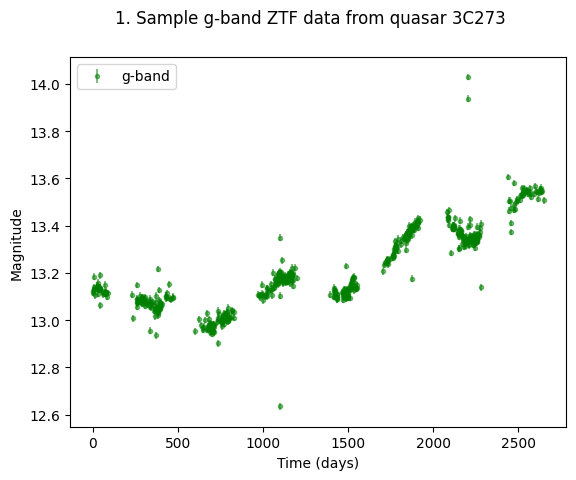

In [5]:
# plotting data + errorbar for chosen filter
ts = df['mjd'].to_numpy()-min(df['mjd'].to_numpy()) # time (in days)
ys = df['mag'].to_numpy() # amplitude (magnitude)
yerrs = df['magerr'].to_numpy() # errorbars

plt.errorbar(ts, ys, yerrs, fmt='.', c='green', alpha=0.5, label='g-band')

plt.suptitle('1. Sample g-band ZTF data from quasar 3C273')
plt.xlabel('Time (days)'); plt.ylabel('Magnitude')
plt.legend()
plt.show()

In [6]:
from numpy.linalg import slogdet, solve

def nll_DRW(params, t, y, sigma):
    """ Calculate negative log likelihood of DRW + constant mean model """
    mu0, log_tau_DRW, log_sigma_DRW = params # unpack params
    
    tau_DRW = np.exp(log_tau_DRW) # DRW timescale
    sigma_DRW = np.exp(log_sigma_DRW) # DRW amplitude
    
    mu = mu0 # constant mean
    r = y - mu # residual/distance
    
    dt = np.abs(t[:, None] - t[None, :]) # time delay matrix 
    K = sigma_DRW**2 * np.exp(-dt / tau_DRW) + np.diag(sigma**2) # cov matrix
    
    sign, logdet = slogdet(K) # log determinant |K|
    quad = r @ solve(K, r) # quad (y-mu)^T K^-1 (y-mu)
    const= len(t) * np.log(2*np.pi) # const N log(2pi)
    
    return 0.5 * (quad + logdet + const)

In [7]:
def log_prior(params):
    """ Calculate flat prior for params of DRW + constant mean model """
    mu0, log_tau_DRW, log_sigma_DRW = params # unpack params

    if not (10 < mu0 < 20): 
        # bounds based on detection and saturation limits of ZTF instrument
        return -np.inf #log(0) --> -infty
    if not (np.log(0.01) < log_tau_DRW < np.log(10000)):
        # bounds based on conservative 0.01x dt_ztf (<~1 day) and 5x baseline_ztf (>~6 years)
        return -np.inf
    if not (np.log(0.01) < log_sigma_DRW < np.log(10)):
        return -np.inf

    return 0.0  #log(1)=0

In [8]:
def log_posterior(params):
    """ Calculate posterior using Baye's rule P(theta|x)~P(x|theta)*P(theta)"""
    return log_prior(params) - nll_DRW(params, ts, ys, yerrs)

In [9]:
# run the metropolis mcmc sampler

# initial guess (mu0, log_tau_DRW, log_sigma_DRW)
theta0 = [np.mean(ys), np.log(10), np.log(0.1)]
sigma = np.array([0.01, 0.1, 0.1])

chain = [theta0]
#n_accepted = 0
n_samples = 5000

chain, chain_logP, acceptance_rate = metropolis_sampler(theta0, log_posterior, sigma, n_samples)

#for _ in range(n_samples-1):
#    chain, accepted = metropolis(chain, log_posterior, sigma)
#    n_accepted += accepted
    
#chain = np.array(chain)
#chain_logP = np.array(chain_logP)
#acceptance_rate = n_accepted/n_samples
print("Acceptance rate:\t", acceptance_rate)

Acceptance rate:	 0.3644


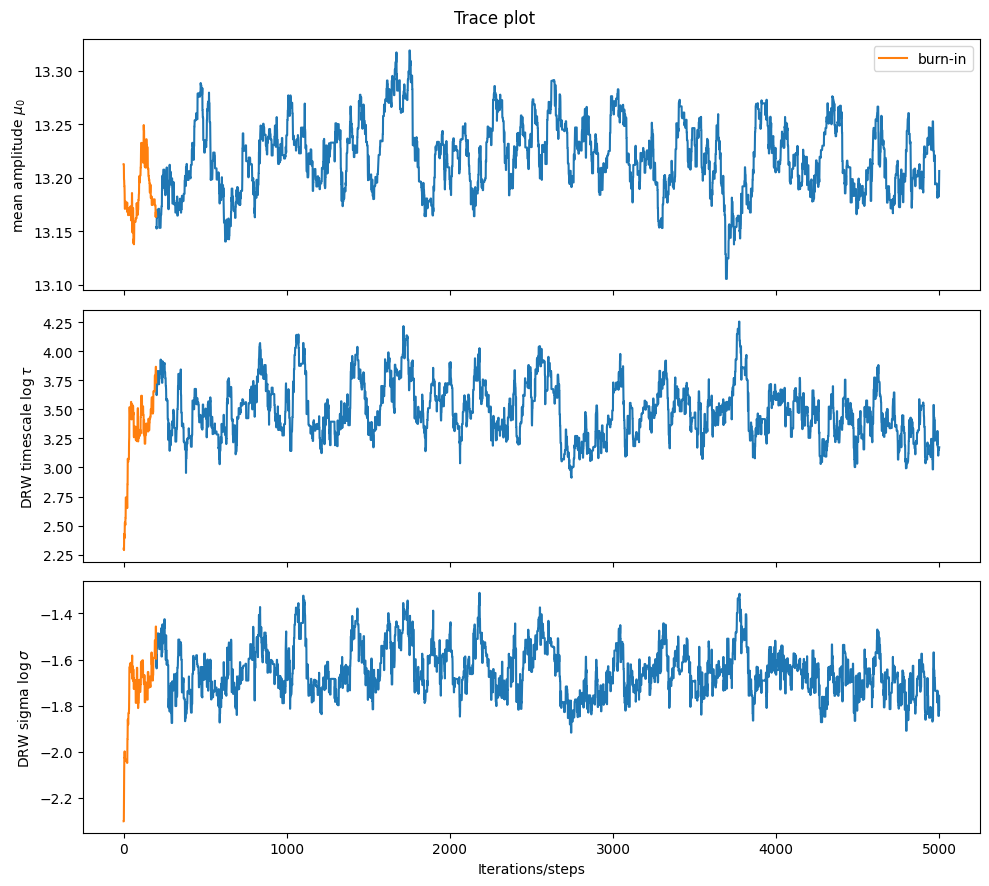

In [10]:
# plot trace
param_labels = [r'mean amplitude $\mu_0$', r'DRW timescale $\log \tau$', r'DRW sigma $\log \sigma$']

burnin = 200
trace_plot(chain, param_labels, burnin)

In [11]:
# remove burn-in
samples = chain[burnin:]

In [18]:
# calculate summary stats
param_map = chain[np.argmax(chain_logP)]
param_median = np.median(samples, axis=0)
low = np.percentile(samples, 16, axis=0) #-1sigma
high = np.percentile(samples, 84, axis=0) #+1sigma

print(f"MAP estimate ({param_labels}):\n\t", param_map)

print("Best fit parameters (median +/- 1sigma):")
for i, lab in enumerate(param_labels):
    print(f"\t{lab} median: {param_median[i]:.4f} (+{high[i]-param_median[i]:.4f}, -{param_median[i]-low[i]:.4f})")

MAP estimate (['mean amplitude $\\mu_0$', 'DRW timescale $\\log \\tau$', 'DRW sigma $\\log \\sigma$']):
	 [13.21664801  3.40606118 -1.69259743]
Best fit parameters (median +/- 1sigma):
	mean amplitude $\mu_0$ median: 13.2207 (+0.0337, -0.0330)
	DRW timescale $\log \tau$ median: 3.4698 (+0.2682, -0.2110)
	DRW sigma $\log \sigma$ median: -1.6605 (+0.1242, -0.0958)


From HW1, Q1:
MLE estimates:
- mu = 13.212639808654785
- log(tau) = log(30.01846574917469) = 3.401812717276848
- log(sigma_drw) = log(0.18401778729312626) = -1.6927228559740632

Problem with mcmc sampled posterior, how do you define best-fit: median? MAP?

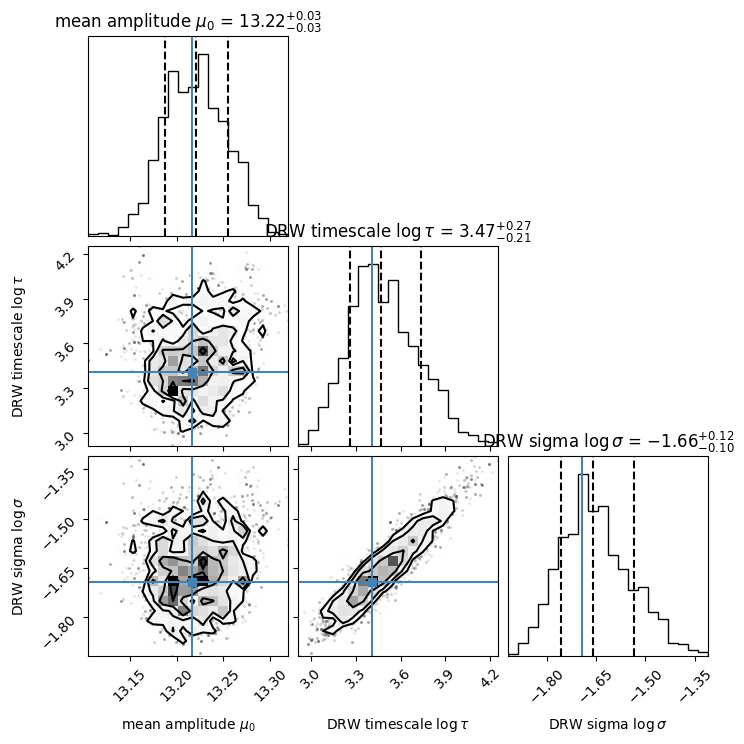

In [14]:
# plot marginalized posteriors
corner.corner(samples, labels=param_labels, show_titles=True, quantiles=[0.16, 0.5, 0.84], truths=param_map)
plt.show()
plt.show()